In [14]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_human_capital import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

par.solver = 'brentq'

model.solve(do_print=True)

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Convergence achieved at iteration 90 with eps = 5.73e-10


The model converges to the steady state:

In [15]:
print(f"Workers supply in high jobs: {[f'{x:.2f}' for x in par.l_h_ss]}")
print(f"Workers supply in low jobs: {[f'{x:.2f}' for x in par.l_l_ss]}")
print(f"Wage of workers in high jobs: {[f'{x:.2f}' for x in par.wage_h_ss]}")
print(f"Wage of workers in low jobs: {[f'{x:.2f}' for x in par.wage_l_ss]}")

Workers supply in high jobs: ['0.00', '0.01', '0.01', '0.01', '0.02', '0.02', '0.03', '0.03', '0.04', '0.04', '0.05', '0.05', '0.06', '0.06', '0.06', '0.07', '0.07', '0.08', '0.09', '0.10', '0.10', '0.10', '0.09', '0.09', '0.08', '0.08', '0.08', '0.08', '0.08', '0.08', '0.07', '0.07', '0.07', '0.07', '0.06', '0.05', '0.04', '0.03', '0.03', '0.02', '0.02', '0.01', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Workers supply in low jobs: ['1.00', '1.00', '1.01', '0.98', '0.96', '0.95', '0.93', '0.92', '0.91', '0.92', '0.89', '0.88', '0.88', '0.85', '0.83', '0.85', '0.84', '0.87', '0.92', '0.94', '0.89', '0.83', '0.75', '0.68', '0.60', '0.57', '0.53', '0.51', '0.47', '0.44', '0.42', '0.39', '0.36', '0.33', '0.31', '0.22', '0.17', '0.14', '0.11', '0.09', '0.06', '0.05', '0.03', '0.01', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00']
Wage of workers in high jobs: ['0.19', '0.19', '0.19', '0.19', '0.20', '0.20', '0.20', '0.21', '0.21', '0.21', '0.22', '0.22', '0.23', '0.23'

In [16]:
model.simulate_transition()

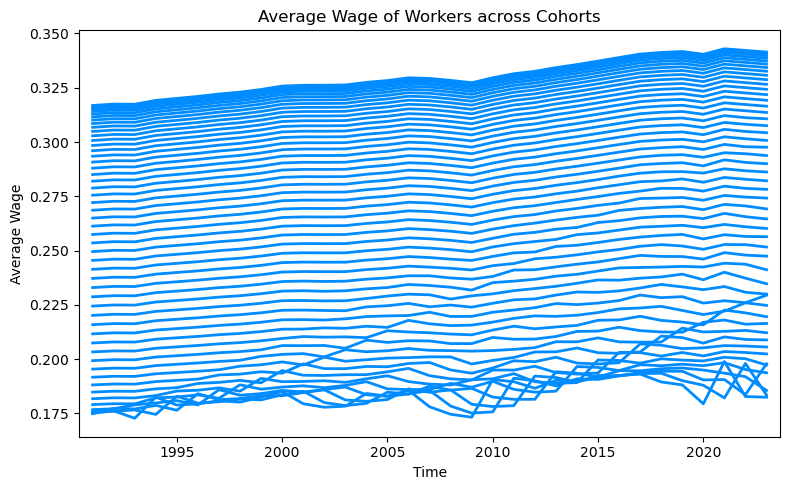

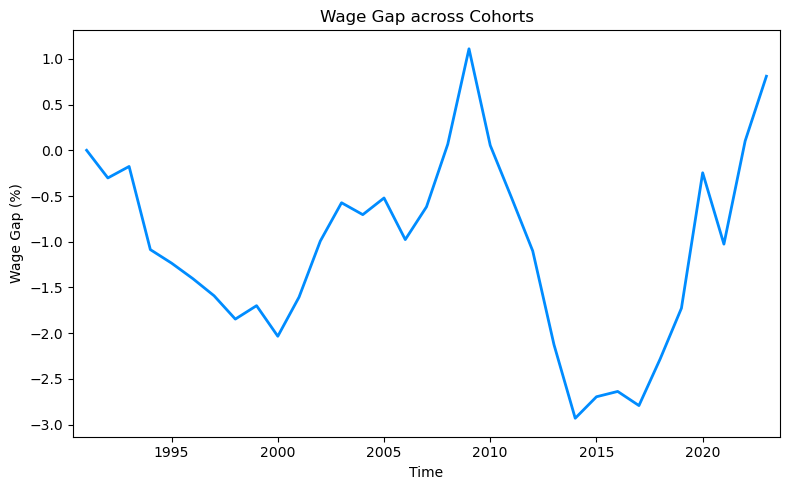

In [17]:
plot_series(model.sim.avg_wage[:, :], title="Average Wage of Workers across Cohorts", ylabel="Average Wage")

wage_gap = (np.average(model.sim.avg_wage[:, -5::]/model.sim.avg_wage[0, -5::], axis=1) - np.average(model.sim.avg_wage[:, :5]/model.sim.avg_wage[0, :5], axis=1))*100
plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")